# RQ3 — Peak-Hour / Diurnal Congestion (9 Countries, NDT7)

กรอบวิเคราะห์ตาม **Lübben & Misfeld (2022)** — หา *busy hour* จากปริมาณการทดสอบต่อชั่วโมง
แล้วดูว่าช่วงคนใช้เยอะทำให้ความเร็วตก / RTT ขึ้นหรือไม่ (congestion)

**ข้อมูล:** `data/exports/ndt7_peakhour_<country>.csv` (สร้างจาก `scripts/build_peakhour.py`)
· ระดับชาติ (pool ทุกจังหวัด) · group = `network_type × type × hour_local × is_weekend`

**วิธี (ตรง HANDOFF §5):**
- `test_time` เป็น **UTC** → แปลงเป็นเวลาท้องถิ่นด้วย offset ต่อประเทศ (TH +7, PH/SG/MY +8, MM +6:30, ID +7 WIB)
  · ยืนยันแล้ว: TH busy hour = 20:00 local (พีคเย็นแบบ L&M)
- ตัด hosting · ตัด throughput≤0 · latency ตัด sentinel (`min_rtt<2000`)
- ใช้ **median/p25/p10** (mean เพี้ยนเพราะ fiber ดึงหาง)

**Degradation วัด 3 แบบ:**
1. **Fixed window** 19–22h vs 03–05h → เทียบข้ามประเทศ apples-to-apples
2. **Empirical** พีคจริงของแต่ละประเทศ vs ชม.เงียบสุดกลางดึก → congestion ตามจริงต่อประเทศ
3. **p10 tail** → เจาะ session แย่สุด 10% (ตอบข้อสังเกตของ paper ว่า complaints เป็นเรื่องหาง)

**ข้อควรระวัง:** ID ใช้ WIB (+7) ทั้งที่คร่อม +7/+8/+9 (limitation) · ข้อมูลกระจุกปี 2025 หนัก
(VN 79%) → ดู bot diagnostic (§6)

> **การอ่านกราฟ:** ทุกกราฟแกน X = **ชั่วโมงท้องถิ่น 0–23** · แกน Y ระบุหน่วยบนแต่ละกราฟ ·
> แถบเทา/ส้ม = ช่วง busy 19–22h · กราฟแท่งมีตัวเลขกำกับหัวแท่ง

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EXPORTS = Path('../../data/exports')
OUT = Path('../../outputs/ndt7/comparison')
OUT.mkdir(parents=True, exist_ok=True)

# เรียงตามขนาด/ภูมิภาคเพื่ออ่านกราฟง่าย
COUNTRIES = ['thailand','vietnam','philippines','singapore','indonesia',
             'malaysia','myanmar','cambodia','laos']
LAB = {c: c.title() for c in COUNTRIES}
TZ  = {'thailand':'UTC+7','vietnam':'UTC+7','cambodia':'UTC+7','laos':'UTC+7',
       'philippines':'UTC+8','singapore':'UTC+8','malaysia':'UTC+8',
       'myanmar':'UTC+6:30','indonesia':'UTC+7 WIB'}
NT_COLOR = {'broadband':'#1f77b4','cellular':'#d62728'}
HRS = 'Local hour of day (0-23, country local time)'   # แกน X มาตรฐานทุกกราฟ

frames = []
for c in COUNTRIES:
    d = pd.read_csv(EXPORTS / f'ndt7_peakhour_{c}.csv')
    d['country'] = c
    frames.append(d)
df = pd.concat(frames, ignore_index=True)
print('loaded', df.shape, '| expect 9*192 =', 9*192)
df.head(3)

loaded (1728, 14) | expect 9*192 = 1728


,network_type,type,hour_local,is_weekend,n_tests,n_ips,med_mbps,p25_mbps,p10_mbps,mean_mbps,med_rtt,mean_rtt,mean_loss,country
0,broadband,download,0,False,381917,254773,38.055194,10.319566,2.431656,101.544770,44.215832,85.691000,0.039030,thailand
1,broadband,download,1,False,239913,180793,37.438502,11.003372,2.634374,99.229277,45.180295,85.478305,0.038133,thailand
2,broadband,download,2,False,162073,101771,37.868103,11.381240,2.645392,99.866318,45.892720,85.522239,0.037083,thailand


In [2]:
# ---- helpers ----
BUSY_W = [19,20,21,22]   # ช่วง busy คงที่ (L&M เยอรมนี 20-22)
OFF_W  = [3,4,5]         # ช่วงเงียบคงที่ (กลางดึก)

def prof(country, nt, typ='download', weekday=True):
    """โปรไฟล์รายชั่วโมง index 0-23 ของ country+network_type (เลือก weekday/weekend)"""
    m = ((df.country==country) & (df.network_type==nt) &
         (df.type==typ) & (df.is_weekend == (not weekday)))
    return df[m].set_index('hour_local').reindex(range(24))

def vol(country, typ='download'):
    """test/ip รวมรายชั่วโมง (รวมทุกวัน รวม bb+cell) — สำหรับหา busy hour แบบ L&M"""
    m = (df.country==country) & (df.type==typ)
    return df[m].groupby('hour_local')[['n_tests','n_ips']].sum().reindex(range(24))

def wmean(country, nt, hours, col='med_mbps', typ='download'):
    """ค่าเฉลี่ยถ่วง n_tests ของ median *รายชั่วโมง* ในหน้าต่าง hours

    ระวัง: นี่คือ weighted mean ของ median รายชั่วโมง **ไม่ใช่ median ของทั้งหน้าต่างรวมกัน**
    (quantile เอามาเฉลี่ยกันแบบนี้ไม่ได้ตามนิยาม) เป็นสถิติสรุปที่ใช้ได้และ consistent
    แต่เวลาเขียนเปเปอร์/caption ต้องเรียกว่า "test-weighted mean of hourly medians"
    ถ้าอยากได้ median จริงของทั้งหน้าต่าง ต้องคำนวณใน SQL รวม 19-22h เป็นก้อนเดียว
    """
    p = prof(country, nt, typ).loc[hours].dropna(subset=[col,'n_tests'])
    return np.average(p[col], weights=p['n_tests']) if len(p) else np.nan

def emp_window(country, nt, typ='download'):
    """พีคจริง: ชม.ที่ test มากสุด vs ชม.เงียบสุด(0-6) ของประเทศนั้นเอง -> (busy,off,ratio)"""
    p = prof(country, nt, typ)
    if p['n_tests'].dropna().empty: return None
    bh = int(p['n_tests'].idxmax())
    night = p.loc[0:6,'n_tests'].dropna()
    oh = int(night.idxmin()) if len(night) else int(p['n_tests'].idxmin())
    return bh, oh, p.loc[bh,'med_mbps'] / p.loc[oh,'med_mbps']

def grouped_bar(ax, frame, value_col, groups, group_col, cats, cat_labels,
                colors, fmt='%.2f', rot=90):
    """วาดกราฟแท่งแบบจัดกลุ่ม + ใส่ตัวเลขบนหัวแท่งให้อัตโนมัติ"""
    x = np.arange(len(cats)); w = 0.8/len(groups)
    for i,g in enumerate(groups):
        sub = (frame[frame[group_col]==g].set_index('country')
               .reindex([LAB[c] for c in cats]))
        bars = ax.bar(x + (i-(len(groups)-1)/2)*w, sub[value_col], w,
                      color=colors[i], label=g)
        ax.bar_label(bars, fmt=fmt, fontsize=7, padding=2, rotation=rot)
    ax.axhline(1, color='k', lw=.9, ls='--')
    ax.text(-0.45, 1.0, '1.0 = no change', fontsize=8, color='gray', va='bottom')
    ax.set_xticks(x); ax.set_xticklabels(cat_labels, rotation=30, ha='right')
    ax.set_xlabel('Country')

def bar_caption(fig, text):
    """คำอธิบายใต้กราฟแท่ง (แนวนอน อ่านง่ายกว่าแกน Y แนวตั้ง) · ใช้คู่กับ savefig(bbox_inches='tight')"""
    fig.text(0.5, -0.03, text, ha='center', va='top', fontsize=9, color='#444')

busy = {c: int(vol(c)['n_tests'].idxmax()) for c in COUNTRIES}

bt = pd.DataFrame({'country':[LAB[c] for c in COUNTRIES],
                   'tz':[TZ[c] for c in COUNTRIES],
                   'busy_hour_local':[f"{busy[c]:02d}:00" for c in COUNTRIES],
                   'total_tests':[int(vol(c)['n_tests'].sum()) for c in COUNTRIES]})
print(bt.to_string(index=False))

    country        tz busy_hour_local  total_tests
   Thailand     UTC+7           20:00     34805933
    Vietnam     UTC+7           11:00     11804903
Philippines     UTC+8           20:00    145765500
  Singapore     UTC+8           22:00     12174460
  Indonesia UTC+7 WIB           20:00    189108236
   Malaysia     UTC+8           20:00      3363921
    Myanmar  UTC+6:30           21:00      1136064
   Cambodia     UTC+7           12:00       420898
       Laos     UTC+7           20:00        66339


## 1. Busy hour — ปริมาณการทดสอบตามชั่วโมงท้องถิ่น
★ = ชั่วโมงที่คนทดสอบมากสุด ถ้าเป็นพฤติกรรมคนจริงควรตกช่วงเย็น (19–22)

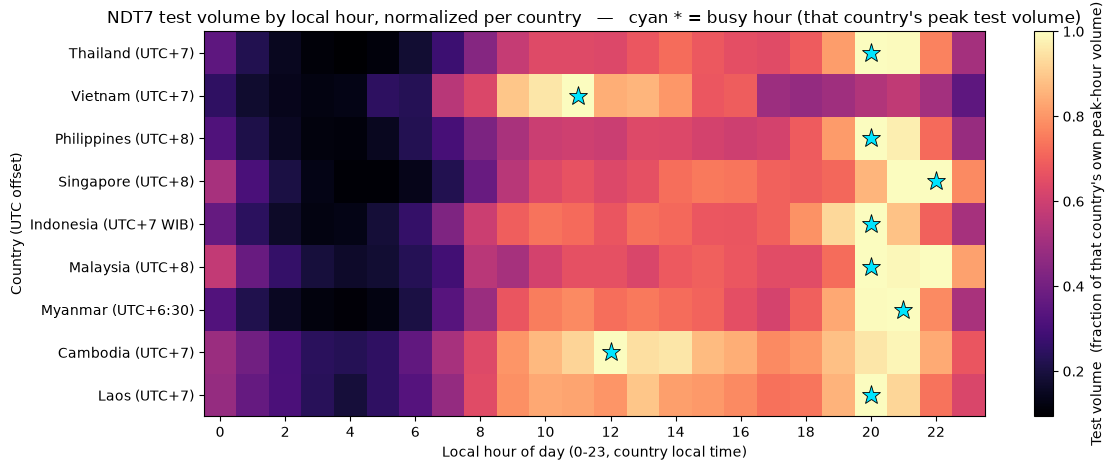

In [3]:
M = np.vstack([vol(c)['n_tests'].values / np.nanmax(vol(c)['n_tests'].values)
                for c in COUNTRIES])
fig, ax = plt.subplots(figsize=(12,4.8))
im = ax.imshow(M, aspect='auto', cmap='magma')
ax.set_xticks(range(0,24,2)); ax.set_xticklabels(range(0,24,2))
ax.set_yticks(range(len(COUNTRIES)))
ax.set_yticklabels([f"{LAB[c]} ({TZ[c]})" for c in COUNTRIES])
for i,c in enumerate(COUNTRIES):
    ax.plot(busy[c], i, marker='*', color='#00e5ff', ms=14, mec='k', mew=.6)
ax.set_xlabel(HRS)
ax.set_ylabel('Country (UTC offset)')
ax.set_title('NDT7 test volume by local hour, normalized per country'
             '   —   cyan * = busy hour (that country\'s peak test volume)')
fig.colorbar(im, ax=ax, label="Test volume  (fraction of that country's own peak-hour volume)")
fig.tight_layout(); fig.savefig(OUT/'rq3_busyhour_heatmap.png', dpi=130); plt.show()

## 2. Diurnal throughput — ความเร็วตกช่วง busy ไหม
ถ้าเส้นตกท้องช่วงแรเงา (19–22) = congestion

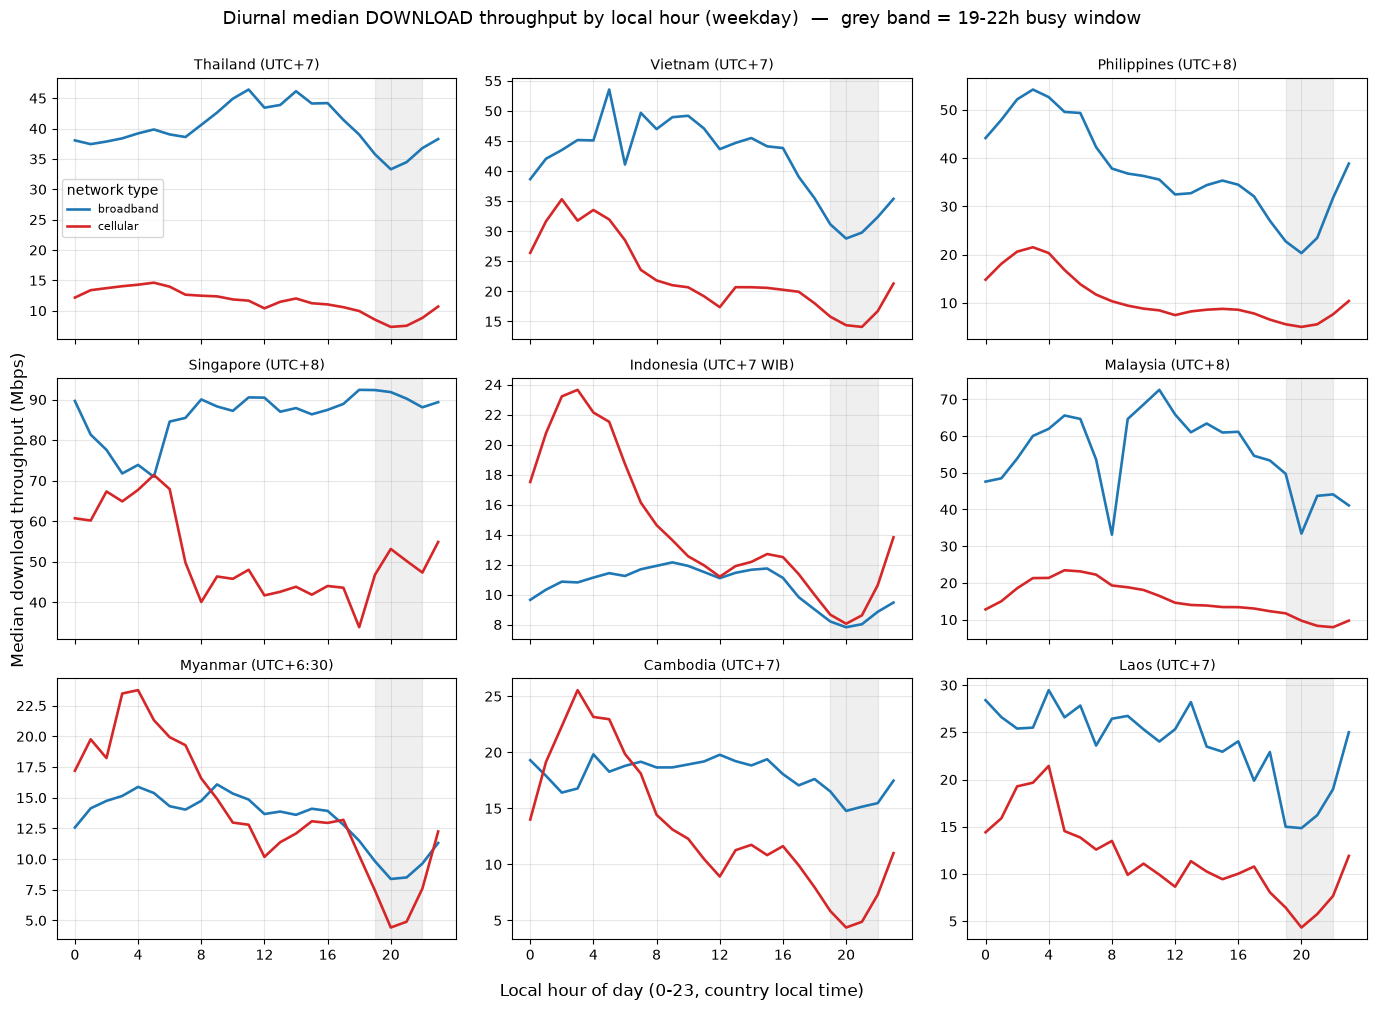

In [4]:
fig, axes = plt.subplots(3,3, figsize=(14,10), sharex=True)
for ax,c in zip(axes.flat, COUNTRIES):
    for nt in ['broadband','cellular']:
        p = prof(c, nt)
        ax.plot(p.index, p['med_mbps'], color=NT_COLOR[nt], label=nt, lw=1.9)
    ax.axvspan(19,22, color='gray', alpha=.12)
    ax.set_title(f"{LAB[c]} ({TZ[c]})", fontsize=10); ax.grid(alpha=.3)
    ax.set_xticks(range(0,24,4))
axes.flat[0].legend(fontsize=8, title='network type')
fig.suptitle('Diurnal median DOWNLOAD throughput by local hour (weekday)'
             '  —  grey band = 19-22h busy window', y=1.0, fontsize=13)
fig.supxlabel(HRS, fontsize=12)
fig.supylabel('Median download throughput (Mbps)', fontsize=12)
fig.tight_layout(); fig.savefig(OUT/'rq3_throughput_diurnal.png', dpi=130); plt.show()

## 2b. Demand ↔ performance overlay
แท่งเทา = ปริมาณ test ต่อชั่วโมง (แกนซ้าย) · เส้นน้ำเงิน = median download broadband (แกนขวา)
**congestion = เส้นตกตรงที่แท่งพุ่ง** (คนใช้เยอะ → ช้าลง)

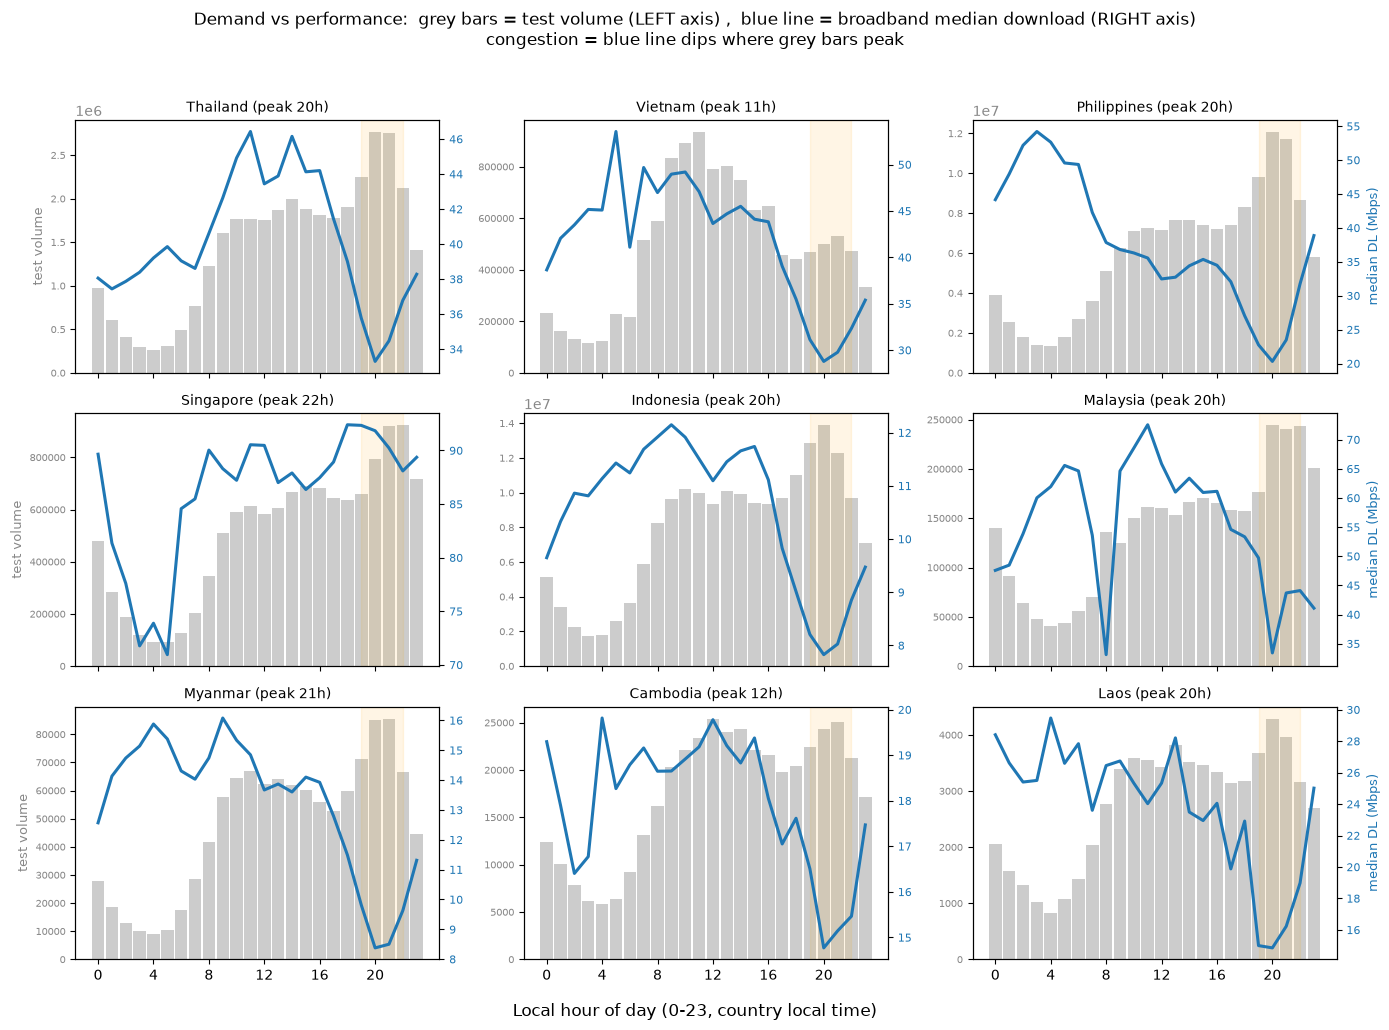

In [5]:
fig, axes = plt.subplots(3,3, figsize=(14,10), sharex=True)
for k,(ax,c) in enumerate(zip(axes.flat, COUNTRIES)):
    v = vol(c)
    ax.bar(v.index, v['n_tests'], color='#cccccc', width=.9)
    ax.set_title(f"{LAB[c]} (peak {busy[c]:02d}h)", fontsize=10)
    ax.tick_params(axis='y', labelsize=7, labelcolor='#888')
    ax.set_xticks(range(0,24,4))
    if k % 3 == 0:
        ax.set_ylabel('test volume', color='#888', fontsize=9)
    ax2 = ax.twinx()
    p = prof(c, 'broadband')
    ax2.plot(p.index, p['med_mbps'], color='#1f77b4', lw=2.2)
    ax2.tick_params(axis='y', labelcolor='#1f77b4', labelsize=8)
    if k % 3 == 2:
        ax2.set_ylabel('median DL (Mbps)', color='#1f77b4', fontsize=9)
    ax.axvspan(19,22, color='orange', alpha=.10)
fig.suptitle('Demand vs performance:  grey bars = test volume (LEFT axis) ,'
             '  blue line = broadband median download (RIGHT axis)'
             '\ncongestion = blue line dips where grey bars peak', y=1.02, fontsize=12)
fig.supxlabel(HRS, fontsize=12)
fig.tight_layout(); fig.savefig(OUT/'rq3_demand_overlay.png', dpi=130); plt.show()

## 3. Diurnal latency (min_rtt) — RTT ขึ้นช่วง busy ไหม

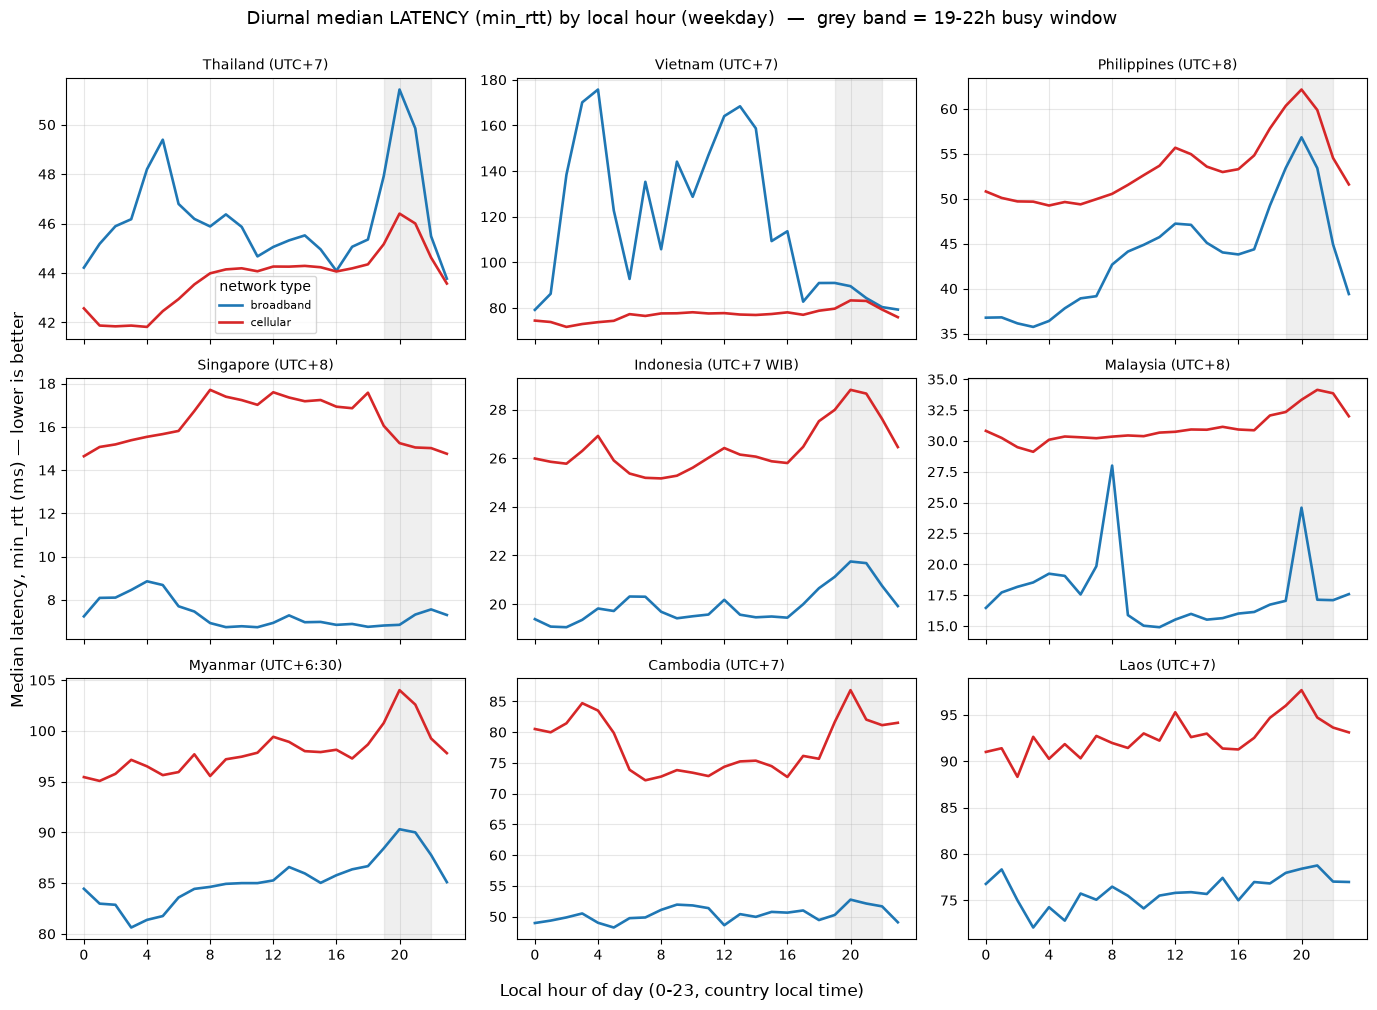

In [6]:
fig, axes = plt.subplots(3,3, figsize=(14,10), sharex=True)
for ax,c in zip(axes.flat, COUNTRIES):
    for nt in ['broadband','cellular']:
        p = prof(c, nt)
        ax.plot(p.index, p['med_rtt'], color=NT_COLOR[nt], label=nt, lw=1.9)
    ax.axvspan(19,22, color='gray', alpha=.12)
    ax.set_title(f"{LAB[c]} ({TZ[c]})", fontsize=10); ax.grid(alpha=.3)
    ax.set_xticks(range(0,24,4))
axes.flat[0].legend(fontsize=8, title='network type')
fig.suptitle('Diurnal median LATENCY (min_rtt) by local hour (weekday)'
             '  —  grey band = 19-22h busy window', y=1.0, fontsize=13)
fig.supxlabel(HRS, fontsize=12)
fig.supylabel('Median latency, min_rtt (ms) — lower is better', fontsize=12)
fig.tight_layout(); fig.savefig(OUT/'rq3_rtt_diurnal.png', dpi=130); plt.show()

## 4. Degradation — Fixed window (เทียบข้ามประเทศ)
`busy(19-22h) / off-peak(03-05h)` ของ **ค่าเฉลี่ยถ่วง n_tests ของ median รายชั่วโมง**
(ไม่ใช่ median ของทั้งหน้าต่าง — ดู docstring ของ `wmean`) · **< 1 = ความเร็วตกช่วง busy = congestion**

    country network_type  busy_mbps  offpeak_mbps  ratio
   Thailand    broadband      34.94         39.15  0.893
   Thailand     cellular       7.97         14.33  0.556
    Vietnam    broadband      30.46         49.34  0.617
    Vietnam     cellular      15.17         32.33  0.469
Philippines    broadband      24.09         51.92  0.464
Philippines     cellular       5.83         19.19  0.304
  Singapore    broadband      90.43         72.19  1.253
  Singapore     cellular      49.42         67.78  0.729
  Indonesia    broadband       8.18         11.17  0.732
  Indonesia     cellular       8.87         22.28  0.398
   Malaysia    broadband      42.04         62.49  0.673
   Malaysia     cellular       9.27         22.05  0.420
    Myanmar    broadband       9.01         15.46  0.583
    Myanmar     cellular       5.94         22.69  0.262
   Cambodia    broadband      15.44         18.26  0.846
   Cambodia     cellular       5.53         23.86  0.232
       Laos    broadband      1

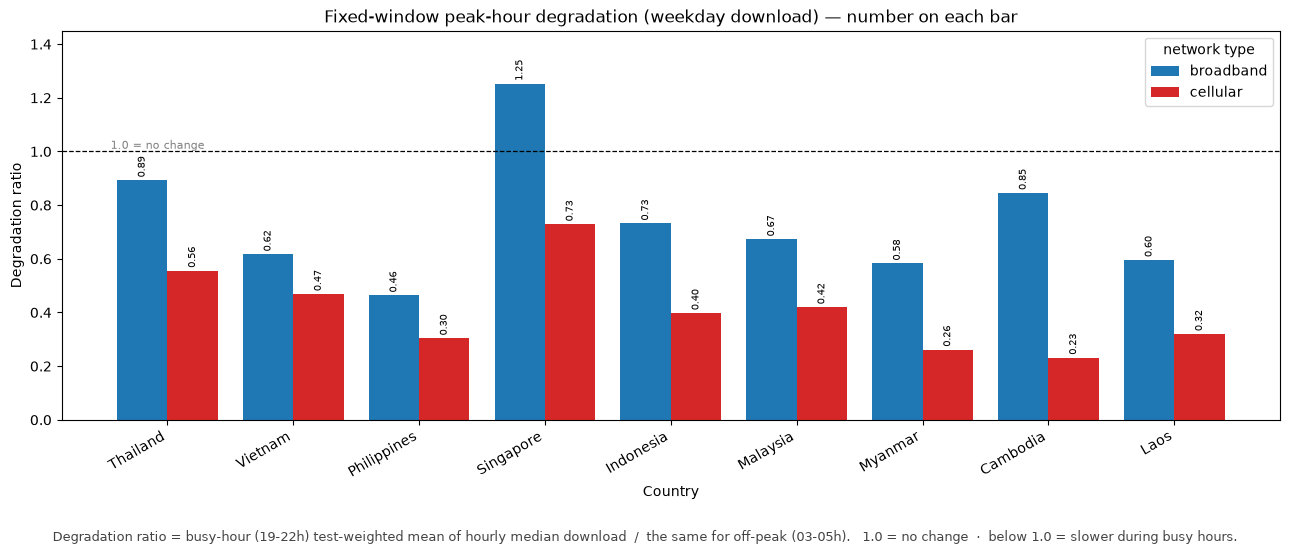

In [7]:
rows=[]
for c in COUNTRIES:
    for nt in ['broadband','cellular']:
        b=wmean(c,nt,BUSY_W); o=wmean(c,nt,OFF_W)
        rows.append(dict(country=LAB[c], network_type=nt,
                         busy_mbps=round(b,2), offpeak_mbps=round(o,2),
                         ratio=round(b/o,3) if o else np.nan))
fx=pd.DataFrame(rows)
print(fx.to_string(index=False))

fig,ax=plt.subplots(figsize=(13,5.2))
grouped_bar(ax, fx, 'ratio', ['broadband','cellular'], 'network_type',
            COUNTRIES, [LAB[c] for c in COUNTRIES], [NT_COLOR['broadband'],NT_COLOR['cellular']])
ax.set_ylim(0, 1.45)
ax.set_ylabel('Degradation ratio')
ax.legend(title='network type')
ax.set_title('Fixed-window peak-hour degradation (weekday download) — number on each bar')
fig.tight_layout()
bar_caption(fig, 'Degradation ratio = busy-hour (19-22h) test-weighted mean of hourly median download  /  the same for off-peak (03-05h).'
                 '   1.0 = no change  ·  below 1.0 = slower during busy hours.')
fig.savefig(OUT/'rq3_degradation_fixed.png', dpi=130, bbox_inches='tight'); plt.show()

## 4b. Tail degradation (p10) — เจาะ "session แย่ที่สุด 10%"
`paper_draft.md` ตั้งข้อสังเกตว่า user complaints เป็นเรื่อง **tail behavior** ไม่ใช่ค่าเฉลี่ย
ที่นี่ทำ fixed-window degradation แต่ใช้ **p10** (ช้าสุด 10%) แทน median → เห็นว่าช่วง busy หางล่างแย่ลงแค่ไหน

network_type  broadband  cellular
country                          
Cambodia          0.622     0.122
Indonesia         0.541     0.242
Laos              0.437     0.281
Malaysia          0.397     0.190
Myanmar           0.200     0.196
Philippines       0.203     0.175
Singapore         0.514     0.346
Thailand          0.544     0.543
Vietnam           0.279     0.307


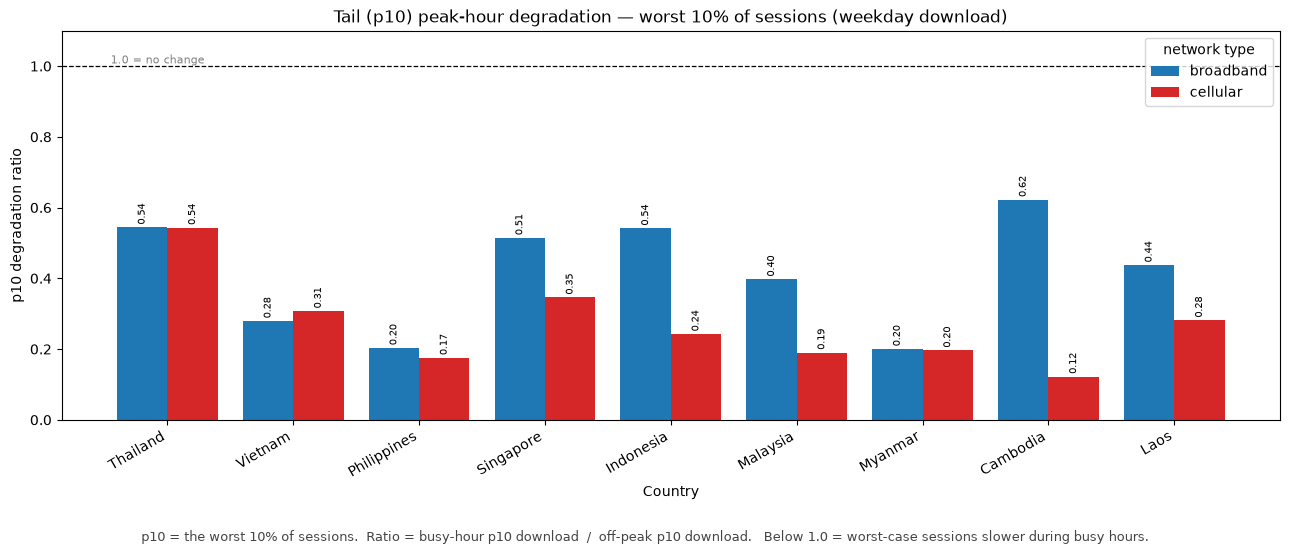

In [8]:
rows=[]
for c in COUNTRIES:
    for nt in ['broadband','cellular']:
        b=wmean(c,nt,BUSY_W,col='p10_mbps'); o=wmean(c,nt,OFF_W,col='p10_mbps')
        rows.append(dict(country=LAB[c], network_type=nt, ratio=round(b/o,3) if o else np.nan))
pt=pd.DataFrame(rows)
print(pt.pivot(index='country',columns='network_type',values='ratio').to_string())

fig,ax=plt.subplots(figsize=(13,5.2))
grouped_bar(ax, pt, 'ratio', ['broadband','cellular'], 'network_type',
            COUNTRIES, [LAB[c] for c in COUNTRIES], [NT_COLOR['broadband'],NT_COLOR['cellular']])
ax.set_ylim(0, 1.1)
ax.set_ylabel('p10 degradation ratio')
ax.legend(title='network type')
ax.set_title('Tail (p10) peak-hour degradation — worst 10% of sessions (weekday download)')
fig.tight_layout()
bar_caption(fig, 'p10 = the worst 10% of sessions.  Ratio = busy-hour p10 download  /  off-peak p10 download.'
                 '   Below 1.0 = worst-case sessions slower during busy hours.')
fig.savefig(OUT/'rq3_degradation_p10.png', dpi=130, bbox_inches='tight'); plt.show()

## 5. Degradation — Empirical (พีคจริงของแต่ละประเทศ)
พีคจริง (test มากสุด) vs ชม.เงียบสุดกลางดึก (0–6) ของประเทศนั้นเอง · รายงานว่าพีคกี่โมงด้วย

    country network_type busy_hr offpeak_hr  ratio
   Thailand    broadband   21:00      04:00  0.879
   Thailand     cellular   20:00      04:00  0.513
    Vietnam    broadband   11:00      03:00  1.043
    Vietnam     cellular   10:00      03:00  0.651
Philippines    broadband   20:00      04:00  0.386
Philippines     cellular   20:00      03:00  0.233
  Singapore    broadband   21:00      05:00  1.272
  Singapore     cellular   21:00      04:00  0.741
  Indonesia    broadband   20:00      03:00  0.724
  Indonesia     cellular   20:00      03:00  0.341
   Malaysia    broadband   20:00      04:00  0.539
   Malaysia     cellular   22:00      04:00  0.372
    Myanmar    broadband   21:00      04:00  0.535
    Myanmar     cellular   20:00      04:00  0.186
   Cambodia    broadband   12:00      04:00  0.998
   Cambodia     cellular   21:00      04:00  0.211
       Laos    broadband   20:00      04:00  0.504
       Laos     cellular   20:00      04:00  0.202


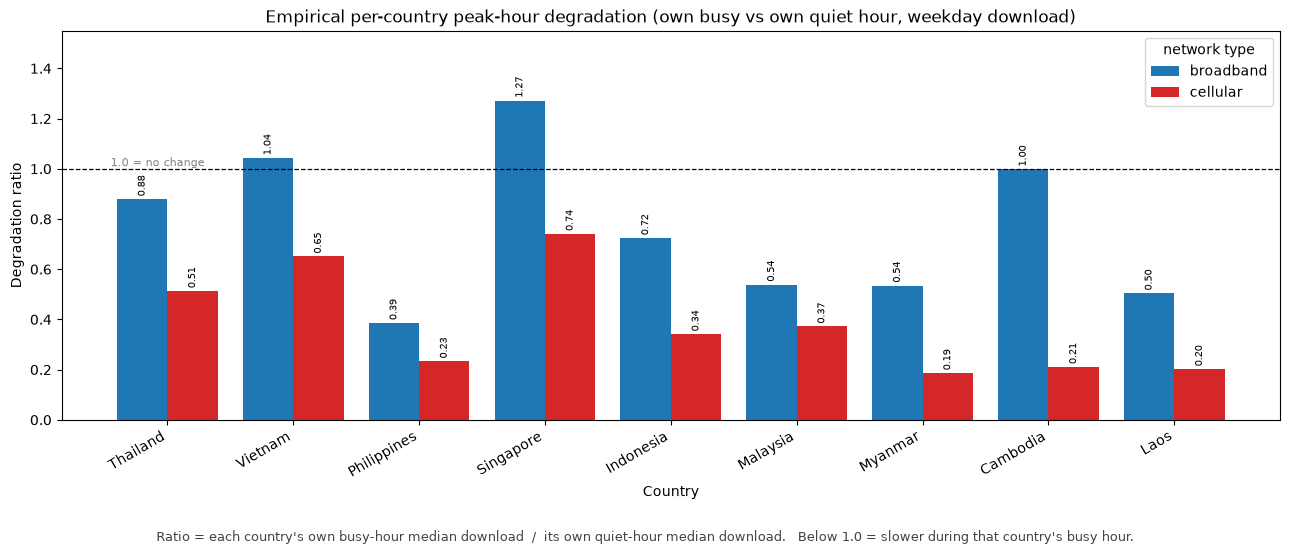

In [9]:
rows=[]
for c in COUNTRIES:
    for nt in ['broadband','cellular']:
        r=emp_window(c,nt)
        if r is None: continue
        bh,oh,ratio=r
        rows.append(dict(country=LAB[c], network_type=nt,
                         busy_hr=f"{bh:02d}:00", offpeak_hr=f"{oh:02d}:00",
                         ratio=round(ratio,3)))
em=pd.DataFrame(rows)
print(em.to_string(index=False))

fig,ax=plt.subplots(figsize=(13,5.2))
grouped_bar(ax, em, 'ratio', ['broadband','cellular'], 'network_type',
            COUNTRIES, [LAB[c] for c in COUNTRIES], [NT_COLOR['broadband'],NT_COLOR['cellular']])
ax.set_ylim(0, 1.55)
ax.set_ylabel('Degradation ratio')
ax.legend(title='network type')
ax.set_title('Empirical per-country peak-hour degradation (own busy vs own quiet hour, weekday download)')
fig.tight_layout()
bar_caption(fig, "Ratio = each country's own busy-hour median download  /  its own quiet-hour median download."
                 "   Below 1.0 = slower during that country's busy hour.")
fig.savefig(OUT/'rq3_degradation_empirical.png', dpi=130, bbox_inches='tight'); plt.show()

## 6. Bot / automated-test diagnostic (Lübben & Misfeld §3.2)
`tests / unique-IP` ต่อชั่วโมง · ค่าสูงหรือ spike แหลม = IP ซ้ำยิงถี่ = ระบบทดสอบอัตโนมัติ ไม่ใช่คนจริง
ช่วยอธิบาย **VN ที่ busy hour ตก 11:00 (ไม่ใช่เย็น)** และประเทศที่ข้อมูลกระจุกปี 2025

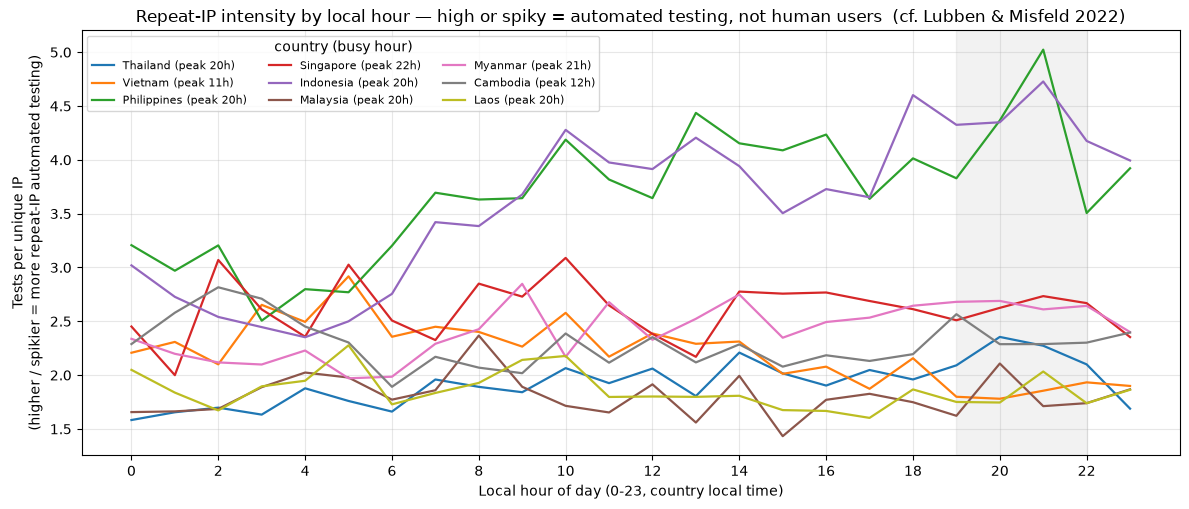

In [10]:
fig,ax=plt.subplots(figsize=(12,5.2))
for c in COUNTRIES:
    v=vol(c); tpi=v['n_tests']/v['n_ips']
    ax.plot(v.index, tpi, label=f"{LAB[c]} (peak {busy[c]:02d}h)", lw=1.6)
ax.axvspan(19,22, color='gray', alpha=.10)
ax.set_xlabel(HRS)
ax.set_ylabel('Tests per unique IP\n(higher / spikier = more repeat-IP automated testing)')
ax.set_title('Repeat-IP intensity by local hour — high or spiky = automated testing, not human users'
             '  (cf. Lubben & Misfeld 2022)')
ax.legend(fontsize=8, ncol=3, title='country (busy hour)'); ax.grid(alpha=.3)
ax.set_xticks(range(0,24,2))
fig.tight_layout(); fig.savefig(OUT/'rq3_bot_diagnostic.png', dpi=130); plt.show()

## 7. Weekday vs weekend (busy-day check)
L&M พบวันจันทร์ยุ่งสุด · ที่นี่ดูว่ารูป diurnal ของ broadband ต่างกันไหมระหว่างวันทำงาน/สุดสัปดาห์

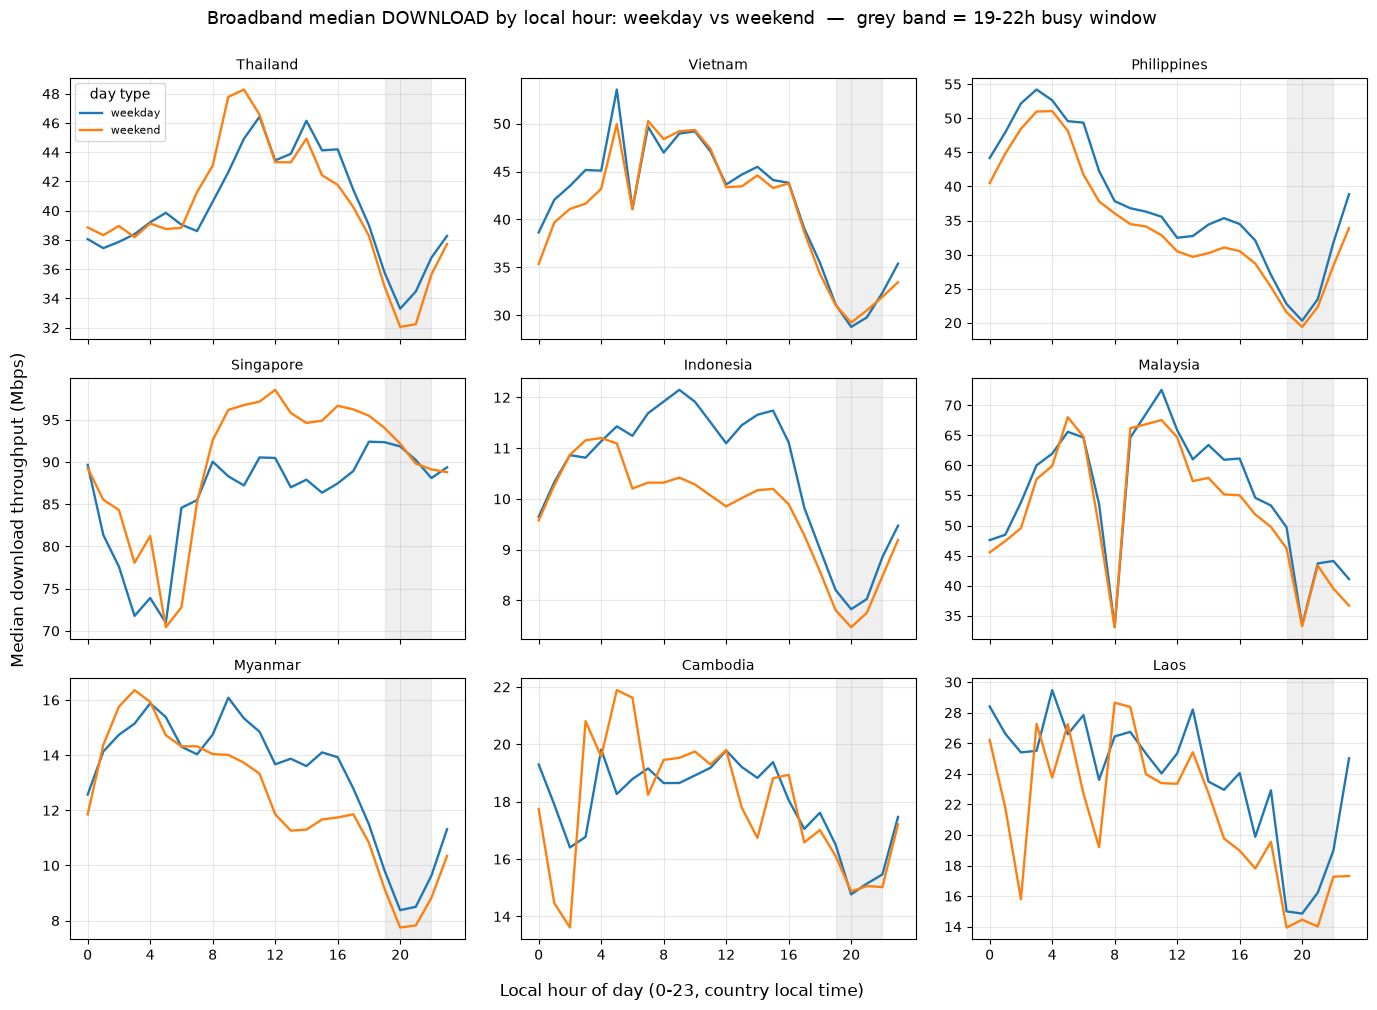

In [11]:
fig, axes = plt.subplots(3,3, figsize=(14,10), sharex=True)
for ax,c in zip(axes.flat, COUNTRIES):
    for wk,color,lab in [(True,'#1f77b4','weekday'),(False,'#ff7f0e','weekend')]:
        p=prof(c,'broadband', weekday=wk)
        ax.plot(p.index, p['med_mbps'], color=color, label=lab, lw=1.7)
    ax.axvspan(19,22, color='gray', alpha=.12)
    ax.set_title(f"{LAB[c]}", fontsize=10); ax.grid(alpha=.3)
    ax.set_xticks(range(0,24,4))
axes.flat[0].legend(fontsize=8, title='day type')
fig.suptitle('Broadband median DOWNLOAD by local hour: weekday vs weekend'
             '  —  grey band = 19-22h busy window', y=1.0, fontsize=13)
fig.supxlabel(HRS, fontsize=12)
fig.supylabel('Median download throughput (Mbps)', fontsize=12)
fig.tight_layout(); fig.savefig(OUT/'rq3_weekday_weekend.png', dpi=130); plt.show()

## 8. Capital vs rest — congestion ในเมืองใหญ่ (8 ประเทศ, ไม่รวม Singapore)
เมืองหลวงคน/อุปกรณ์หนาแน่นกว่า — busy-hour congestion หนักกว่าส่วนอื่นไหม?
Singapore ตัดออกเพราะไม่มี periphery ให้เทียบ (city-state, ดู §4.2 ของเปเปอร์)
(จาก `ndt7_peakhour_capital_<c>.csv` · capital = Bangkok / Hanoi / NCR / Jakarta / Kuala Lumpur /
Phnom Penh / Vientiane / Yangon)

**08-14: เพิ่ม kh/la/mm แก้ equal-scope violation** — เดิมเข้าใจผิดว่าเมืองหลวง 3 ประเทศนี้ข้อมูลไม่พอ
ที่จริง PhnomPenh 70.8%, Vientiane[prefecture] 65.1%, Yangon 48.3% ของ test ในประเทศ (data-thick,
ยืนยันจาก `build_peakhour.py --capital`)

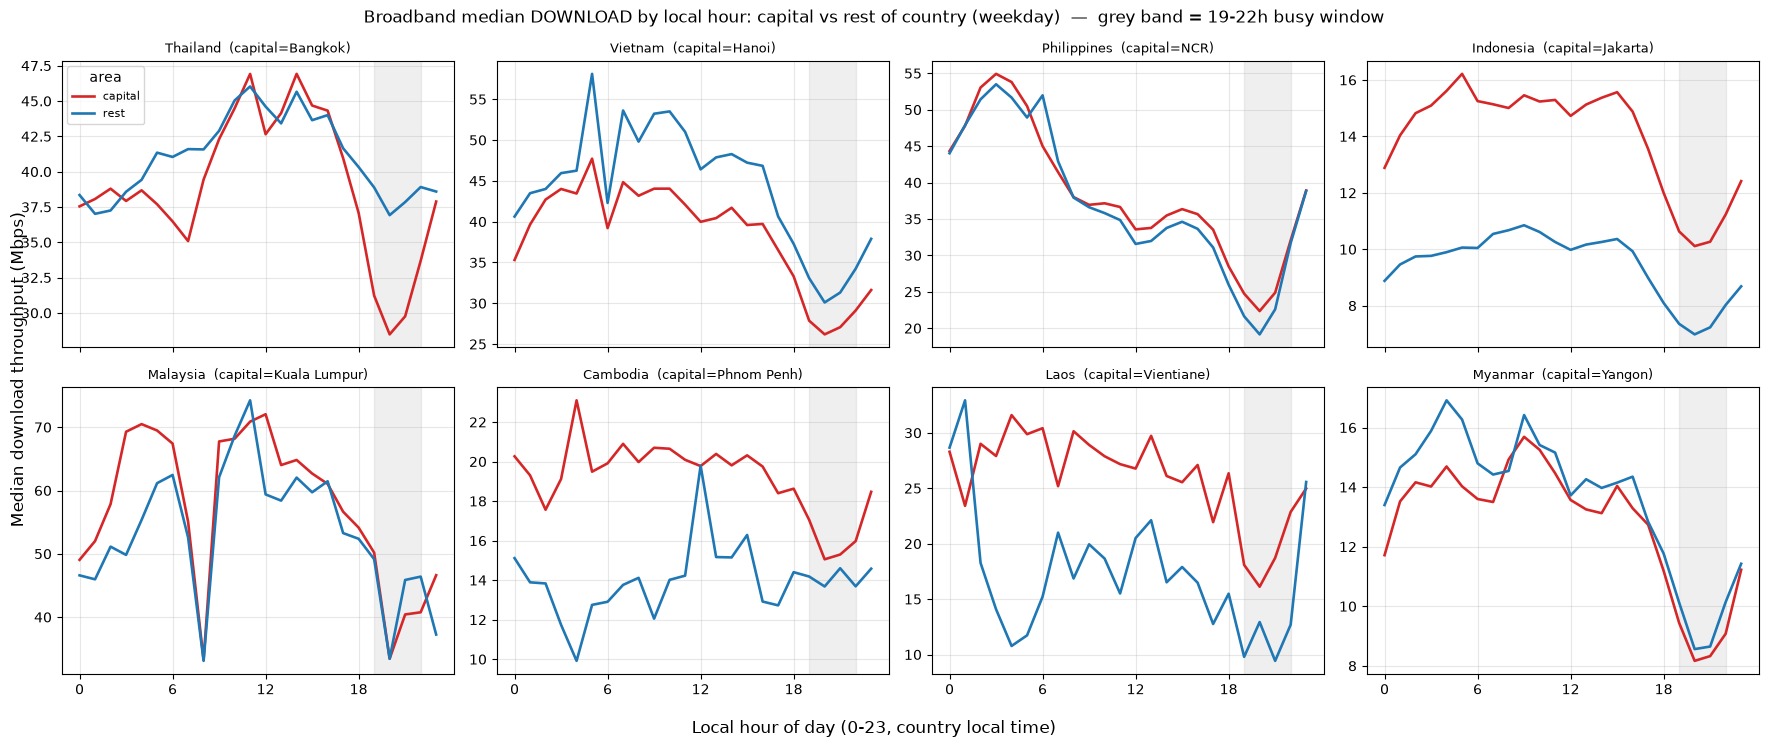

In [12]:
CAP8 = ['thailand','vietnam','philippines','indonesia','malaysia',
        'cambodia','laos','myanmar']
CAP_NAME = {'thailand':'Bangkok','vietnam':'Hanoi','philippines':'NCR',
            'indonesia':'Jakarta','malaysia':'Kuala Lumpur',
            'cambodia':'Phnom Penh','laos':'Vientiane','myanmar':'Yangon'}
capframes=[]
for c in CAP8:
    d=pd.read_csv(EXPORTS/f'ndt7_peakhour_capital_{c}.csv'); d['country']=c; capframes.append(d)
capdf=pd.concat(capframes, ignore_index=True)

def cprof(country, area, nt, typ='download', weekday=True):
    m=((capdf.country==country)&(capdf.area==area)&(capdf.network_type==nt)&
       (capdf.type==typ)&(capdf.is_weekend==(not weekday)))
    return capdf[m].set_index('hour_local').reindex(range(24))

def cwmean(country, area, nt, hours, col='med_mbps', typ='download'):
    p=cprof(country,area,nt,typ).loc[hours].dropna(subset=[col,'n_tests'])
    return np.average(p[col], weights=p['n_tests']) if len(p) else np.nan

# diurnal broadband: capital vs rest
fig,axes=plt.subplots(2,4,figsize=(18,7.5),sharex=True)
for ax,c in zip(axes.flat,CAP8):
    for area,color in [('capital','#d62728'),('rest','#1f77b4')]:
        p=cprof(c,area,'broadband')
        ax.plot(p.index,p['med_mbps'],color=color,label=area,lw=1.9)
    ax.axvspan(19,22,color='gray',alpha=.12)
    ax.set_title(f"{LAB[c]}  (capital={CAP_NAME[c]})",fontsize=9); ax.grid(alpha=.3)
    ax.set_xticks(range(0,24,6))
axes.flat[0].legend(fontsize=8, title='area')
fig.suptitle('Broadband median DOWNLOAD by local hour: capital vs rest of country (weekday)'
             '  —  grey band = 19-22h busy window', fontsize=12)
fig.supxlabel(HRS, fontsize=12)
fig.supylabel('Median download throughput (Mbps)', fontsize=12)
fig.tight_layout(); fig.savefig(OUT/'rq3_capital_vs_rest.png', dpi=130); plt.show()

busy/off-peak degradation (<1 = congestion):
network_type broadband        cellular       
area           capital   rest  capital   rest
country                                      
Cambodia         0.770  1.219    0.277  0.144
Indonesia        0.668  0.740    0.362  0.428
Laos             0.630  0.921    0.351  0.251
Malaysia         0.581  0.774    0.428  0.404
Myanmar          0.611  0.568    0.283  0.222
Philippines      0.486  0.453    0.254  0.353
Thailand         0.804  0.956    0.556  0.566
Vietnam          0.602  0.616    0.470  0.468


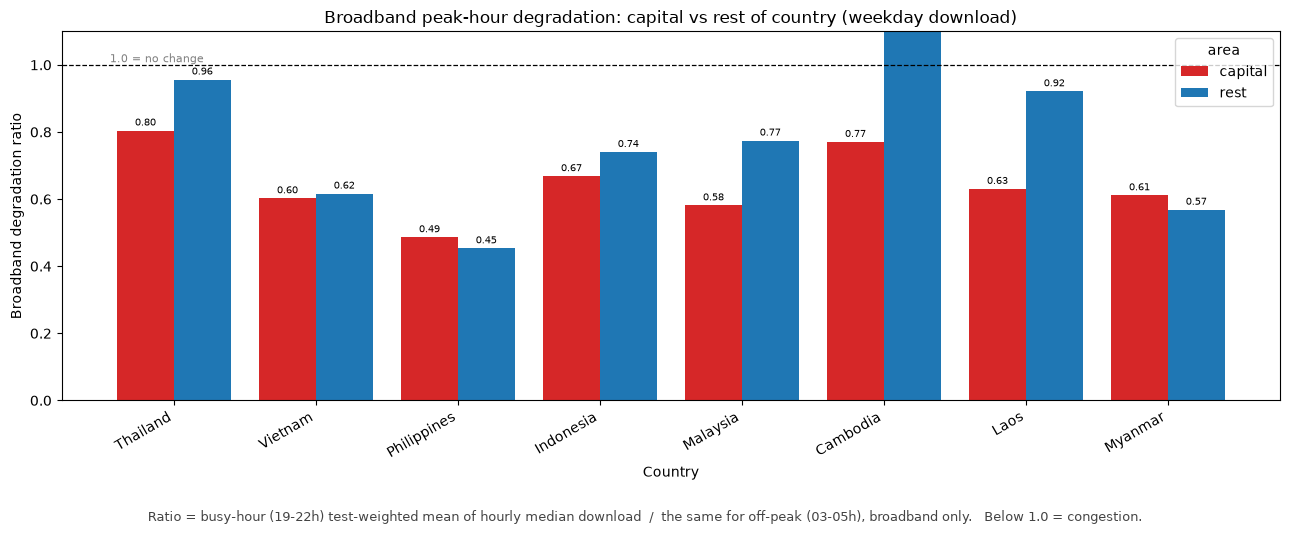

In [13]:
# degradation (fixed 19-22 vs 03-05) capital vs rest
rows=[]
for c in CAP8:
    for area in ['capital','rest']:
        for nt in ['broadband','cellular']:
            b=cwmean(c,area,nt,BUSY_W); o=cwmean(c,area,nt,OFF_W)
            rows.append(dict(country=LAB[c], area=area, network_type=nt,
                             busy_mbps=round(b,1), degr=round(b/o,3) if o else np.nan))
cap=pd.DataFrame(rows)
piv=cap.pivot_table(index='country', columns=['network_type','area'], values='degr')
print('busy/off-peak degradation (<1 = congestion):'); print(piv.to_string())
cap.to_csv(OUT/'rq3_capital_summary.csv', index=False)

# bar: broadband degradation capital vs rest
bb = cap[cap.network_type=='broadband']
fig,ax=plt.subplots(figsize=(13,5))
grouped_bar(ax, bb, 'degr', ['capital','rest'], 'area',
            CAP8, [LAB[c] for c in CAP8], ['#d62728','#1f77b4'], rot=0)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Broadband degradation ratio')
ax.legend(title='area')
ax.set_title('Broadband peak-hour degradation: capital vs rest of country (weekday download)')
fig.tight_layout()
bar_caption(fig, 'Ratio = busy-hour (19-22h) test-weighted mean of hourly median download  /  the same for off-peak (03-05h), broadband only.'
                 '   Below 1.0 = congestion.')
fig.savefig(OUT/'rq3_capital_degradation.png', dpi=130, bbox_inches='tight'); plt.show()

## 9. สรุป — export ตาราง

In [14]:
summ=[]
for c in COUNTRIES:
    row=dict(country=LAB[c], tz=TZ[c], busy_hour=f"{busy[c]:02d}:00",
             total_tests=int(vol(c)['n_tests'].sum()))
    for nt in ['broadband','cellular']:
        b=wmean(c,nt,BUSY_W); o=wmean(c,nt,OFF_W)
        row[f'{nt}_busy_mbps']=round(b,2) if b==b else np.nan
        row[f'{nt}_offpeak_mbps']=round(o,2) if o==o else np.nan
        row[f'{nt}_degr_fixed']=round(b/o,3) if o else np.nan
        b10=wmean(c,nt,BUSY_W,col='p10_mbps'); o10=wmean(c,nt,OFF_W,col='p10_mbps')
        row[f'{nt}_degr_p10']=round(b10/o10,3) if o10 else np.nan
        r=emp_window(c,nt)
        if r: row[f'{nt}_degr_emp']=round(r[2],3)
    summ.append(row)
S=pd.DataFrame(summ)
S.to_csv(OUT/'rq3_peakhour_summary.csv', index=False)
print('saved ->', (OUT/'rq3_peakhour_summary.csv').resolve())
S

saved -> /home/chissanupun/Desktop/code/lab/cnc/data-science/internet-measurement/outputs/ndt7/comparison/rq3_peakhour_summary.csv


,country,tz,busy_hour,total_tests,broadband_busy_mbps,broadband_offpeak_mbps,broadband_degr_fixed,broadband_degr_p10,broadband_degr_emp,cellular_busy_mbps,cellular_offpeak_mbps,cellular_degr_fixed,cellular_degr_p10,cellular_degr_emp
0,Thailand,UTC+7,20:00,34805933,34.94,39.15,0.893,0.544,0.879,7.97,14.33,0.556,0.543,0.513
1,Vietnam,UTC+7,11:00,11804903,30.46,49.34,0.617,0.279,1.043,15.17,32.33,0.469,0.307,0.651
2,Philippines,UTC+8,20:00,145765500,24.09,51.92,0.464,0.203,0.386,5.83,19.19,0.304,0.175,0.233
3,Singapore,UTC+8,22:00,12174460,90.43,72.19,1.253,0.514,1.272,49.42,67.78,0.729,0.346,0.741
4,Indonesia,UTC+7 WIB,20:00,189108236,8.18,11.17,0.732,0.541,0.724,8.87,22.28,0.398,0.242,0.341
5,Malaysia,UTC+8,20:00,3363921,42.04,62.49,0.673,0.397,0.539,9.27,22.05,0.420,0.190,0.372
6,Myanmar,UTC+6:30,21:00,1136064,9.01,15.46,0.583,0.200,0.535,5.94,22.69,0.262,0.196,0.186
7,Cambodia,UTC+7,12:00,420898,15.44,18.26,0.846,0.622,0.998,5.53,23.86,0.232,0.122,0.211
8,Laos,UTC+7,20:00,66339,16.14,27.08,0.596,0.437,0.504,5.89,18.37,0.320,0.281,0.202
